# Sensor Variability Analysis

## Objective

The purpose of this notebook is to analyze the behavior and variability of all sensor measurements in the NASA CMAPSS dataset.

The analysis aims to answer the following questions:

- Do all sensors change over time?
- Which sensors have very low or zero variance?
- Which sensors appear nearly constant?
- Which sensors exhibit high variability?
- Are there sensors that may not contribute useful predictive information?

The results of this notebook will guide future feature selection and preprocessing decisions.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.data.loader import DataLoader
from src.data.validator import DataValidator
from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH,
)

In [4]:
loader = DataLoader(
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

validator = DataValidator(
    train_df,
    test_df,
    rul_df
)

validator.validate_all()

2026-07-20 21:25:03 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-07-20 21:25:05 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-07-20 21:25:05 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-07-20 21:25:06 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-07-20 21:25:06 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-07-20 21:25:06 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully
2026-07-20 21:25:06 | INFO | validator.py | Line:40 | Validating training dataset...
2026-07-20 21:25:06 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-07-20 21:25:06 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

In [5]:
sensor_columns = [
    col for col in train_df.columns
    if col.startswith("sensor")
]

print(sensor_columns)

['sensor_1', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_5', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21']


In [6]:
sensor_variance = (
    train_df[sensor_columns]
    .var()
    .sort_values()
)

sensor_variance

sensor_16         0.000022
sensor_10         0.016302
sensor_15         0.563061
sensor_11        10.520237
sensor_5         13.125202
sensor_19        28.830710
sensor_6         29.637316
sensor_21        35.553759
sensor_20        98.731968
sensor_1        698.906067
sensor_17       773.300629
sensor_2       1394.473263
sensor_14      7339.442015
sensor_3      11271.558809
sensor_4      14239.073899
sensor_13     16434.691116
sensor_12     19176.463675
sensor_8      21126.111710
sensor_18     21162.245693
sensor_7      21573.795950
sensor_9     113520.171620
dtype: float64

In [7]:
sensor_std = (
    train_df[sensor_columns]
    .std()
    .sort_values()
)

sensor_std

sensor_16      0.004685
sensor_10      0.127681
sensor_15      0.750374
sensor_11      3.243492
sensor_5       3.622872
sensor_19      5.369424
sensor_6       5.444017
sensor_21      5.962697
sensor_20      9.936396
sensor_1      26.436832
sensor_17     27.808283
sensor_2      37.342647
sensor_14     85.670543
sensor_3     106.167598
sensor_4     119.327591
sensor_13    128.197859
sensor_12    138.479109
sensor_8     145.348243
sensor_18    145.472491
sensor_7     146.880210
sensor_9     336.927547
dtype: float64

In [8]:
unique_values = (
    train_df[sensor_columns]
    .nunique()
    .sort_values()
)

unique_values

sensor_16        2
sensor_19        2
sensor_5         6
sensor_1         6
sensor_18        6
sensor_10       21
sensor_6        46
sensor_17       54
sensor_13      483
sensor_20      652
sensor_11      737
sensor_8      1038
sensor_2      1704
sensor_12     5627
sensor_7      5926
sensor_15    11915
sensor_3     13558
sensor_14    15938
sensor_4     17353
sensor_21    21574
sensor_9     25297
dtype: int64

In [ ]:
## Summary Table

sensor_summary = pd.DataFrame({
    "Variance": train_df[sensor_columns].var(),
    "Std": train_df[sensor_columns].std(),
    "Unique Values": train_df[sensor_columns].nunique(),
    "Min": train_df[sensor_columns].min(),
    "Max": train_df[sensor_columns].max(),
    "Mean": train_df[sensor_columns].mean(),
})

sensor_summary.sort_values("Variance")

,Variance,Std,Unique Values,Min,Max,Mean
sensor_16,0.000022,0.004685,2,0.0200,0.0300,0.023252
sensor_10,0.016302,0.127681,21,0.9300,1.3200,1.096445
sensor_15,0.563061,0.750374,11915,8.1757,11.0663,9.285604
sensor_11,10.520237,3.243492,737,36.0400,48.3600,42.874529
sensor_5,13.125202,3.622872,6,3.9100,14.6200,8.031626
sensor_19,28.830710,5.369424,2,84.9300,100.0000,97.751396
sensor_6,29.637316,5.444017,46,5.6700,21.6100,11.589457
sensor_21,35.553759,5.962697,21574,6.0843,23.8852,12.518995
sensor_20,98.731968,9.936396,652,10.1600,39.8900,20.864333
sensor_1,698.906067,26.436832,6,445.0000,518.6700,472.882435


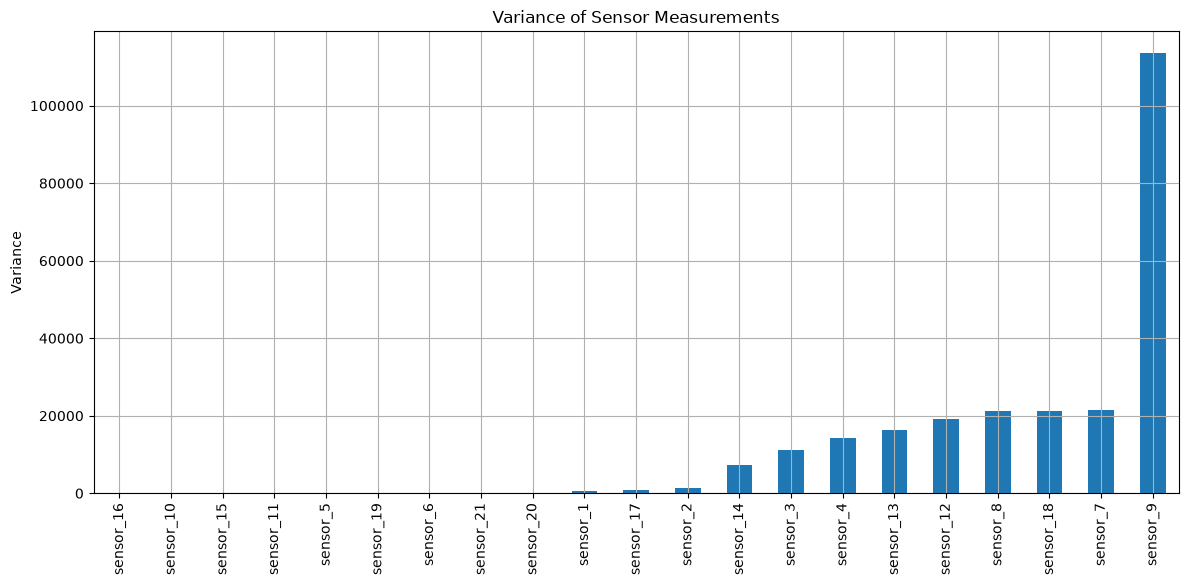

In [ ]:
plt.figure(figsize=(14,6))
sensor_variance.plot(kind="bar")

plt.title("Variance of Sensor Measurements")
plt.ylabel("Variance")
plt.grid(True)
plt.show()

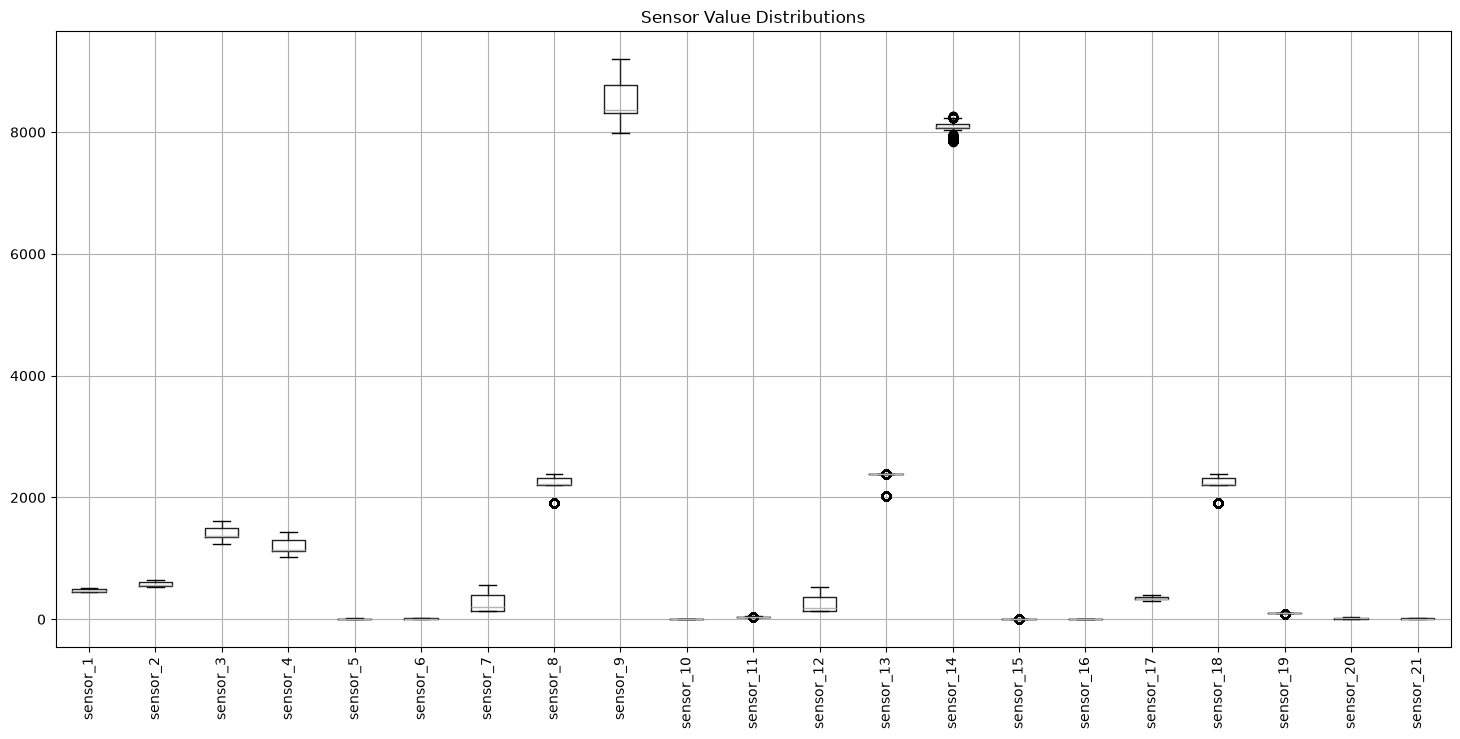

In [12]:
plt.figure(figsize=(18,8))

train_df[sensor_columns].boxplot(
    rot=90
)

plt.title("Sensor Value Distributions")
plt.show()

<Axes: >

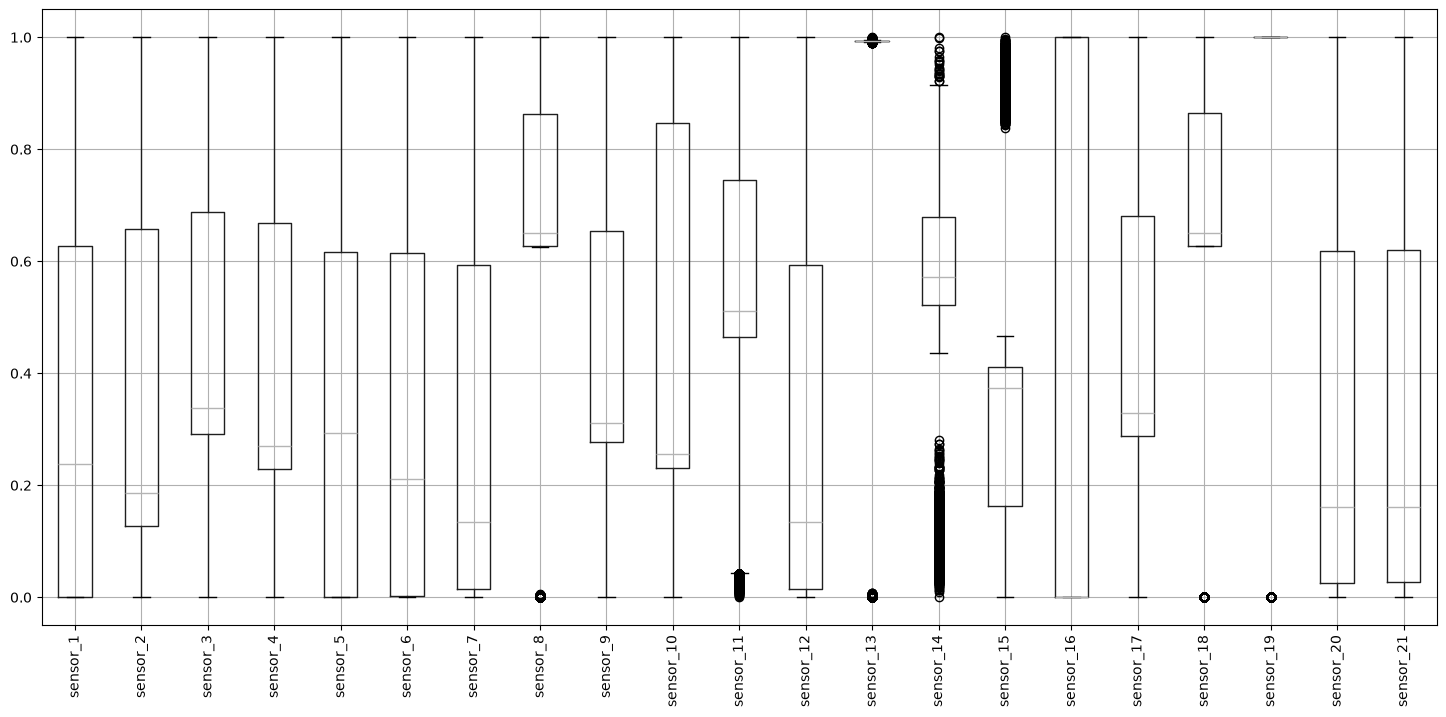

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

normalized = pd.DataFrame(
    scaler.fit_transform(train_df[sensor_columns]),
    columns=sensor_columns
)

normalized.boxplot(
    figsize=(18,8),
    rot=90
)

# Observations

## Sensor Variability

The sensors exhibit substantially different levels of variability.

Variance ranges from approximately **2.2 × 10⁻⁵** (Sensor 16) to more than **113,000** (Sensor 9), indicating large differences in measurement dynamics.

---

## Low-Variance Sensors

Several sensors display extremely limited variability.

Examples include:

- Sensor 16
- Sensor 10

These sensors are potential candidates for removal but require additional investigation before any decision is made.

---

## Low-Cardinality Sensors

Some sensors contain only a small number of unique values.

Examples:

- Sensor 16 (2 unique values)
- Sensor 19 (2 unique values)
- Sensor 5 (6 unique values)
- Sensor 18 (6 unique values)

These may represent discrete operating states rather than continuous measurements.

---

## High-Variance Sensors

Sensors such as Sensor 9, Sensor 7, Sensor 8 and Sensor 18 exhibit substantial variability across the dataset.

However, high variance alone does not imply high predictive power.

Further temporal analysis is required.

---

The normalized boxplots provide a scale-independent comparison of all sensor distributions.

### Key Findings (Normalized Boxplots)

- Sensor 16 exhibits an almost binary distribution, confirming the statistical results obtained from the variance analysis.
- Sensor 19 also shows a very limited number of distinct values, suggesting it may represent a discrete operating condition rather than a continuously varying sensor.
- Sensor 15 contains a substantial number of outliers, indicating either strong variability or sensitivity to different operating regimes.
- Sensors 8 and 18 display broad distributions with large interquartile ranges, suggesting considerable variation throughout the dataset.
- Most remaining sensors exhibit well-distributed values without obvious abnormalities.

Overall, the normalized visualization supports the numerical variability analysis and highlights several sensors that warrant further investigation.

# Engineering Decisions

## Decision 1 — Preserve All Sensors

No sensors will be removed solely based on variance.

Although Sensor 16 exhibits extremely low variance, additional analyses are required before determining whether it contributes useful degradation information.

---

## Decision 2 — Investigate Low-Cardinality Sensors

Sensors with only a few unique values (e.g., Sensor 16 and Sensor 19) will be investigated further to determine whether they encode operating conditions or contain predictive degradation patterns.

---

## Decision 3 — Continue Correlation Analysis

Variance does not reveal redundancy between sensors.

The next stage will analyze pairwise correlations to identify highly correlated sensor groups.

---

## Decision 4 — Analyze Temporal Degradation

The predictive value of each sensor depends on how it evolves throughout an engine's lifetime rather than on its overall variance.

The next notebook will examine sensor trajectories with respect to engine cycles.

---

## Decision 5 — Delay Feature Elimination

Feature selection decisions will only be made after combining evidence from:

- Variance analysis
- Correlation analysis
- Temporal degradation analysis
- Relationship with Remaining Useful Life (RUL)